# 02 Training and Evaluation

Run `python train.py` first, then use this notebook to inspect test performance and the confusion matrix.

In [5]:
import os
import sys

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import confusion_matrix, classification_report

PROJECT_ROOT = os.path.abspath('..')
if not os.path.isdir(os.path.join(PROJECT_ROOT, 'data')) and os.path.isdir('data'):
    PROJECT_ROOT = os.getcwd()

sys.path.append(PROJECT_ROOT)
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
MODEL_PATH = os.path.join(PROJECT_ROOT, 'emotion_detector.pth')

from dataset import get_loaders
from model import get_model

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
_, _, test_loader, classes = get_loaders(data_dir=DATA_DIR)
model = get_model(num_classes=len(classes), freeze_backbone=False).to(DEVICE)

if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
else:
    print(f'Checkpoint not found at {MODEL_PATH}; using randomly initialized weights.')

model.eval()

Checkpoint not found at /Users/a/Projects Helwan 2026/AML/emotion_detector.pth; using randomly initialized weights.


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Test accuracy: 0.0794 (7.9%)
              precision    recall  f1-score   support

       angry       0.00      0.00      0.00       486
     disgust       0.02      0.23      0.04        56
        fear       0.00      0.00      0.00       514
       happy       0.13      0.03      0.05       906
     neutral       0.17      0.15      0.16       591
         sad       0.07      0.00      0.00       616
    surprise       0.07      0.36      0.11       420

    accuracy                           0.08      3589
   macro avg       0.07      0.11      0.05      3589
weighted avg       0.08      0.08      0.05      3589



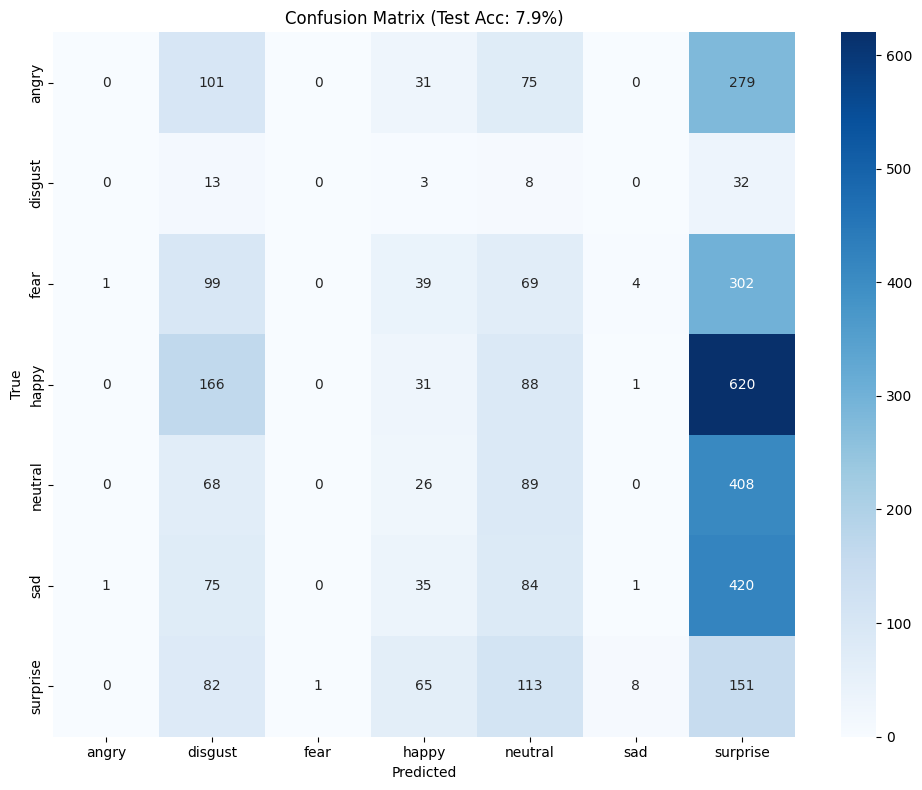

In [6]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(DEVICE))
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f'Test accuracy: {accuracy:.4f} ({accuracy * 100:.1f}%)')
print(classification_report(all_labels, all_preds, target_names=classes))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.title(f'Confusion Matrix (Test Acc: {accuracy * 100:.1f}%)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()